<a href="https://colab.research.google.com/github/eugeniaapvt/Student-Performance-Data-Processing-Integration/blob/main/Student_Performance_Data_Processing_%26_Integration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TUGAS 2 MANAJEMEN BIG DATA**

**Student Performance and Attendance Dataset**

Sumber : Kaggle

Kelompok E

Nama Anggota :
1. Imelda Lovena (M0724013)
2. Eugenia Bening Sekar Pavita (M0724025)
3. Natlea Yosseva Charissandy (M0724039)

# Cleaning Messy Data dan Data Manipulation

1. Import Data

In [ ]:
import pandas as pd
import numpy as np
import os

2. Mengaitkan ke google drive untuk mengakses file yang sudah disimpan

In [ ]:
# Menggunakan directory google drive
from google.colab import drive
drive.mount('/content/drive')

os.chdir("/content/drive/MyDrive")
print(os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive


3. Membaca data dari ketiga file CSV ke dalam dataframe

In [ ]:
students = pd.read_csv("Dataset MBD/students.csv")
attendance = pd.read_csv("Dataset MBD/attendance.csv")
performance = pd.read_csv("Dataset MBD/performance.csv")

4. Membersihkan kolom status kehadiran dan mengubah semua tulisan menjadi huruf kecil serta menyamakan istilah yang sama

In [ ]:
# Mengubah semua value di 'Attendance_Status' menjadi huruf kecil
attendance['Attendance_Status'] = attendance['Attendance_Status'].str.lower()

# Menyamakan semua value menjadi 'present' dan 'absent'
value_mapping = {
    'present ': 'present',
    'excused': 'absent',
    'late': 'present',
    'absnt': 'absent',
    'left early': 'present'
}
attendance['Attendance_Status'] = attendance['Attendance_Status'].replace(value_mapping)

# Melihat nilai unik di kolom 'Attendance_Status'
print("\nUnique values Attendance_Status setelah standarisasi:")
print(attendance['Attendance_Status'].unique())


Unique values Attendance_Status setelah standarisasi:
['present' 'absent' ' late']


5. Membuat huruf pertama dari setiap nama siswa menjadi huruf besar

In [ ]:
# Kapitalisasikan huruf pertama setiap kata di kolom 'Full_Name'
students['Full_Name'] = students['Full_Name'].str.title()

# Menampilkan beberapa baris pertama dataframe students untuk memverifikasi
print("\nStudents dataframe setelah standarisasi 'Full_Name':")
display(students.head())


Students dataframe setelah standarisasi 'Full_Name':


,Student_ID,Full_Name,Date_of_Birth,Grade_Level,Emergency_Contact
0,S00001,Donna Williams,2007-02-10,Grade 3,781-534-4258x9046
1,S00002,John Stafford,2014-11-26,Grade 5,+1-782-691-6291x99704
2,S00003,Chad Harper,2017-02-07,Grade 3,308.517.3750
3,S00004,Anthony Martin,11-10-2014,Grade 5,306-771-1524x116
4,S00005,Mary Stone,04-01-2016,Grade 3,+1-794-484-8495x7772


6. Membuat tanggal lahir siswa dan tanggal kehadiran menjadi format yang sama

In [ ]:
# Ubah 'Date_of_Birth' students ke datetime (format mixed)
students['Date_of_Birth'] = pd.to_datetime(students['Date_of_Birth'], errors='coerce', format='mixed', dayfirst=True)

# Ubah 'Date' attendance ke datetime (format mixed)
attendance['Date'] = pd.to_datetime(attendance['Date'], format='mixed', dayfirst=True)

# Display datatypes
print("Data types setelah konversi tanggal:")
print("\nStudents:")
print(students.dtypes)
print("\nAttendance:")
print(attendance.dtypes)

Data types setelah konversi tanggal:

Students:
Student_ID                   object
Full_Name                    object
Date_of_Birth        datetime64[ns]
Grade_Level                  object
Emergency_Contact            object
dtype: object

Attendance:
Student_ID                   object
Date                 datetime64[ns]
Subject                      object
Attendance_Status            object
dtype: object


7. Interpretasi

Dalam tahap ini, data yang tidak rapi seperti status kehadiran yang tidak standar dan nama yang tidak konsisten dirapikan, format tanggal diseragamkan, lalu data dari berbagai sumber digabungkan. Tujuannya agar data menjadi akurat dan terstruktur.

# Merging dan Concatenating

1. Menggabungkan dataframe attendance dan performance berdasarkan kolom Student_ID dan Subject menggunakan left merged

In [ ]:
# Merge attendance, homework, dan performance dataframes berdasarkan 'Student_ID' and 'Subject'
merged_df = pd.merge(attendance, performance, on=['Student_ID', 'Subject'], how='left')

# Display dataframe
display(merged_df)

,Student_ID,Date,Subject,Attendance_Status,Exam_Score,Homework_Completion_%,Teacher_Comments
0,S06592,2024-09-20,Arabic,present,NaN,NaN,NaN
1,S01777,2025-01-22,Math,present,NaN,NaN,NaN
2,S07362,2024-12-03,Geography,present,NaN,NaN,NaN
3,S12119,2024-03-16,Geography,absent,61.0,80%,Couple program black include my control home f...
4,S12119,2024-03-16,Geography,absent,93.0,90,Big film determine sense great mission wear mo...
...,...,...,...,...,...,...,...
402976,S08595,2025-02-14,Math,present,NaN,NaN,NaN
402977,S11222,2025-03-06,Science,present,NaN,NaN,NaN
402978,S11344,2024-04-18,History,present,NaN,NaN,NaN
402979,S04381,2024-10-04,Science,present,47.0,95,Office large because address radio avoid take ...


2. Menggabungkan dataframe yang sudah digabung sebelumnya dengan dataframe siswa  berdasarkan kolom Student_ID menggunakan left merged

In [ ]:
# Merge merged_df dataframe dengan students dataframe
merged_df = pd.merge(merged_df, students, on='Student_ID', how='left')

# Display dataframe
display(merged_df)

,Student_ID,Date,Subject,Attendance_Status,Exam_Score,Homework_Completion_%,Teacher_Comments,Full_Name,Date_of_Birth,Grade_Level,Emergency_Contact
0,S06592,2024-09-20,Arabic,present,NaN,NaN,NaN,Dylan Harris,2008-04-20,Grade 4,713-902-2708
1,S01777,2025-01-22,Math,present,NaN,NaN,NaN,Kristin Freeman,2013-09-21,Grade 5,(708)584-8533
2,S07362,2024-12-03,Geography,present,NaN,NaN,NaN,Robin Green,2015-05-19,Grade 1,001-283-734-3266
3,S12119,2024-03-16,Geography,absent,61.0,80%,Couple program black include my control home f...,Henry Parker Md,2017-02-24,Grade 3,(918)392-7344x996
4,S12119,2024-03-16,Geography,absent,93.0,90,Big film determine sense great mission wear mo...,Henry Parker Md,2017-02-24,Grade 3,(918)392-7344x996
...,...,...,...,...,...,...,...,...,...,...,...
402976,S08595,2025-02-14,Math,present,NaN,NaN,NaN,Timothy Smith,2013-04-08,Grade 1,499.524.4716
402977,S11222,2025-03-06,Science,present,NaN,NaN,NaN,Steven Adams,2018-11-23,Grade 4,+1-469-641-7153x85585
402978,S11344,2024-04-18,History,present,NaN,NaN,NaN,Glen Hess,2012-11-29,Grade 1,+1-909-632-6160x631
402979,S04381,2024-10-04,Science,present,47.0,95,Office large because address radio avoid take ...,Brandi Cole,2011-03-26,Grade 5,001-389-967-5736x49244


3. Menghapus kolom 'Homework_Completion_%', 'Teacher_Comments', 'Date_of_Birth', dan 'Emergency_Contact' dari dataframe

In [ ]:
# Drop kolom yang tidak diperlukan
merged_df = merged_df.drop(columns=['Homework_Completion_%', 'Teacher_Comments', 'Date_of_Birth', 'Emergency_Contact'])

# Display dataframe head
display(merged_df.head())

,Student_ID,Date,Subject,Attendance_Status,Exam_Score,Full_Name,Grade_Level
0,S06592,2024-09-20,Arabic,present,NaN,Dylan Harris,Grade 4
1,S01777,2025-01-22,Math,present,NaN,Kristin Freeman,Grade 5
2,S07362,2024-12-03,Geography,present,NaN,Robin Green,Grade 1
3,S12119,2024-03-16,Geography,absent,61.0,Henry Parker Md,Grade 3
4,S12119,2024-03-16,Geography,absent,93.0,Henry Parker Md,Grade 3


4. Interpretasi

Dalam tahap ini, menggabungkan tiga tabel data siswa (kehadiran, nilai, dan data pribadi) menjadi satu tabel besar. Kemudian kolom 'Homework_Completion_%', 'Teacher_Comments', 'Date_of_Birth', 'Emergency_Contact' kita hapus karena tidak relevan. Tujuannya supaya bisa melihat hubungan antara kehadiran, nilai, dan data siswa.

# Detecting dan Handling Duplicate Data

1. Menampilkan jumlah baris duplikat dalam dataframe

In [ ]:
# Cek duplikat rows
duplikat_rows = merged_df.duplicated().sum()

print(f"\nJumlah baris duplikat dalam dataframe: {duplikat_rows}")


Jumlah baris duplikat dalam dataframe: 1850


2. Membuat bar plot untuk menampilkan jumlah baris duplikat sebelum dihapus

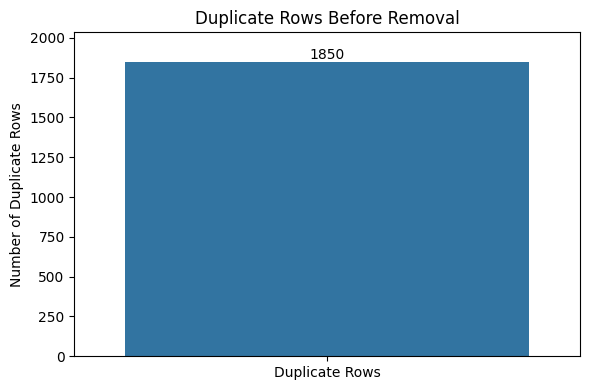

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung jumlah baris duplikat sebelum dihapus
duplicate_before = merged_df.duplicated().sum()

# Buat bar chart untuk menampilkan jumlah duplikat
plt.figure(figsize=(6, 4))
sns.barplot(x=['Duplicate Rows'], y=[duplicate_before])

plt.title('Duplicate Rows Before Removal')
plt.ylabel('Number of Duplicate Rows')
plt.ylim(0, duplicate_before * 1.1)  # Membuat ruang sedikit di atas batang untuk label

# Tampilkan nilai
plt.text(0, duplicate_before, str(duplicate_before), ha='center', va='bottom')

plt.tight_layout()
plt.show()

3. Menghapus baris duplikat dari dataframe, hanya menyisakan baris pertama yang muncul jika ada duplikat

In [ ]:
# Drop duplikat, pertahankan baris pertama
merged_df = merged_df.drop_duplicates(keep='first')

# Display head
display(merged_df.head())

# Verifikasi tidak ada duplikat lagi
duplicates_after_drop = merged_df.duplicated().sum()
print(f"\nJumlah baris duplikat dalam dataframe setelah dihapus: {duplicates_after_drop}")

,Student_ID,Date,Subject,Attendance_Status,Exam_Score,Full_Name,Grade_Level
0,S06592,2024-09-20,Arabic,present,NaN,Dylan Harris,Grade 4
1,S01777,2025-01-22,Math,present,NaN,Kristin Freeman,Grade 5
2,S07362,2024-12-03,Geography,present,NaN,Robin Green,Grade 1
3,S12119,2024-03-16,Geography,absent,61.0,Henry Parker Md,Grade 3
4,S12119,2024-03-16,Geography,absent,93.0,Henry Parker Md,Grade 3



Jumlah baris duplikat dalam dataframe setelah dihapus: 0


4. Membuat bar plot untuk menampilkan jumlah baris duplikat setelah dihapus

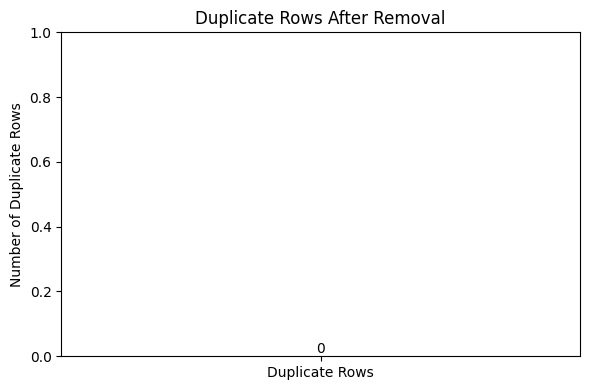

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung jumlah baris duplikat setelah dihapus
duplicate_after = merged_df.duplicated().sum()

# Buat bar chart untuk menampilkan jumlah duplikat setelah dihapus
plt.figure(figsize=(6, 4))
sns.barplot(x=['Duplicate Rows'], y=[duplicate_after])

plt.title('Duplicate Rows After Removal')
plt.ylabel('Number of Duplicate Rows')
plt.ylim(0, max(duplicate_after * 1.1, 1)) # beri batas atas agar label terlihat, minimal 1

# Tampilkan nilai
plt.text(0, duplicate_after, str(duplicate_after), ha='center', va='bottom')

plt.tight_layout()
plt.show()

5. Interpretasi

Dalam tahap ini, detecting dan handling duplicate supaya setiap baris data itu unik. Tujuannya mencegah data yang sama terhitung berkali-kali, sehingga analisis jadi lebih akurat dan datanya lebih bersih.

# Detecting dan Handling Missing Value

1. Menampilkan jumlah nilai yang hilang di setiap kolom dalam dataframe

In [ ]:
# Cek missing values setiap kolom
missing_values = merged_df.isnull().sum()

# Display jumlah missing values setiap kolom
print("\nMissing values setiap kolom:")
print(missing_values)


Missing values setiap kolom:
Student_ID                0
Date                      0
Subject                   0
Attendance_Status         0
Exam_Score           220614
Full_Name                 0
Grade_Level               0
dtype: int64


2. Membuat bar plot untuk menunjukkan jumlah nilai yang hilang pada kolom 'Exam_Score' sebelum handling missing value

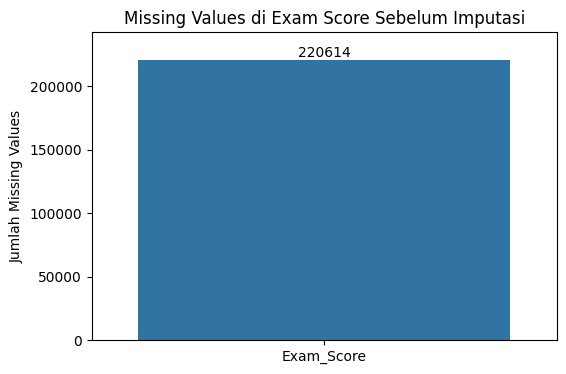

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cek missing value sebelum imputasi
missing_values_before = merged_df['Exam_Score'].isnull().sum()

# Buat bar chart untuk menampilkan jumlah missing value di 'Exam_Score'
plt.figure(figsize=(6, 4))
sns.barplot(x=['Exam_Score'], y=[missing_values_before])
plt.title('Missing Values di Exam Score Sebelum Imputasi')
plt.ylabel('Jumlah Missing Values')
plt.ylim(0, missing_values_before * 1.1) # Atur y-limit lebih tinggi agar visualisasi jelas
plt.text(0, missing_values_before, str(missing_values_before), ha='center', va='bottom') # Tambah label
plt.show()

3. Menghitung rata-rata nilai ujian per mata pelajaran dan mengisi nilai yang hilang di kolom 'Exam_Score' dengan rata-rata tersebut

In [ ]:
# Hitung rata-rata Exam_Score per Subject
mean_per_subject = merged_df.groupby('Subject')['Exam_Score'].transform('mean')

# Imputasi missing values di Exam_Score dengan rata-rata per subject
merged_df = merged_df.copy() # Buat copy untuk menghindari error
merged_df['Exam_Score'] = merged_df['Exam_Score'].fillna(mean_per_subject)

# Verifikasi
print("\nMissing values Exam_Score setelah imputation:")
print(merged_df['Exam_Score'].isnull().sum())

# Display dataframe
display(merged_df.head())


Missing values Exam_Score setelah imputation:
0


,Student_ID,Date,Subject,Attendance_Status,Exam_Score,Full_Name,Grade_Level
0,S06592,2024-09-20,Arabic,present,74.933893,Dylan Harris,Grade 4
1,S01777,2025-01-22,Math,present,74.750456,Kristin Freeman,Grade 5
2,S07362,2024-12-03,Geography,present,74.562018,Robin Green,Grade 1
3,S12119,2024-03-16,Geography,absent,61.000000,Henry Parker Md,Grade 3
4,S12119,2024-03-16,Geography,absent,93.000000,Henry Parker Md,Grade 3


4. Membuat bar plot untuk menunjukkan jumlah nilai yang hilang pada kolom 'Exam_Score' setelah nilai yang hilang diisi

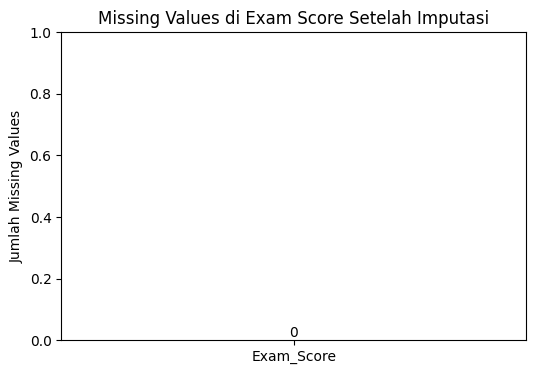

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cek missing value setelah imputasi
missing_values_after = merged_df['Exam_Score'].isnull().sum()

# Buat bar chart untuk menampilkan jumlah missing value di 'Exam_Score'
plt.figure(figsize=(6, 4))
sns.barplot(x=['Exam_Score'], y=[missing_values_after])
plt.title('Missing Values di Exam Score Setelah Imputasi')
plt.ylabel('Jumlah Missing Values')
plt.ylim(0, max(missing_values_after * 1.1, 1)) # Set y-limit, ensuring it's at least 1 if missing_values_after is 0
plt.text(0, missing_values_after, str(missing_values_after), ha='center', va='bottom') # Add text label
plt.show()

5. Interpretasi

Dalam tahap ini, detecting dan handling missing value dilakukan untuk mengidentifikasi nilai yang hilang, terutama pada 'Exam_Score', dan mengisinya dengan rata-rata per mata pelajaran. Tujuannya supaya data lengkap dan menghindari hasil yang tidak akurat akibat data yang kosong.

# Detecting dan Handling Outlier

1. Menampilkan apakah ada nilai pada kolom 'Exam_Score' yang lebih besar dari 100

In [ ]:
# Cek Exam_Score yang lebih besar dari 100
exam_scores_lebih_100 = merged_df[merged_df['Exam_Score'] > 100]

# Display baris dengan Exam_Score > 100
if not exam_scores_lebih_100.empty:
    print("\nBaris dengan Exam_Score lebih dari 100:")
    display(exam_scores_lebih_100)
else:
    print("\nTidak ada Exam_Score yang lebih dari 100.")


Baris dengan Exam_Score lebih dari 100:


,Student_ID,Date,Subject,Attendance_Status,Exam_Score,Full_Name,Grade_Level
16,S01258,2024-05-08,Geography,present,107.0,Matthew Fletcher,Grade 2
24,S04730,2025-01-28,History,present,107.0,Michael Greer,Grade 2
30,S00923,2024-10-07,Science,absent,105.0,Melissa Sullivan,Grade 4
31,S00923,2024-10-07,Science,absent,101.0,Melissa Sullivan,Grade 4
76,S09880,2024-05-05,Math,present,110.0,Joanne Newton,Grade 2
...,...,...,...,...,...,...,...
402841,S02078,2024-11-27,History,present,106.0,Robert Rodriguez,Grade 5
402853,S11425,2024-04-27,English,present,102.0,Michelle Hammond,Grade 1
402860,S04994,2024-10-14,History,present,103.0,Dennis Moore,Grade 5
402900,S12051,2024-10-17,Science,absent,110.0,Timothy Keller,Grade 2


2. Membuat box plot dari kolom 'Exam_Score' untuk mendeteksi outlier sebelum dilakukan handling

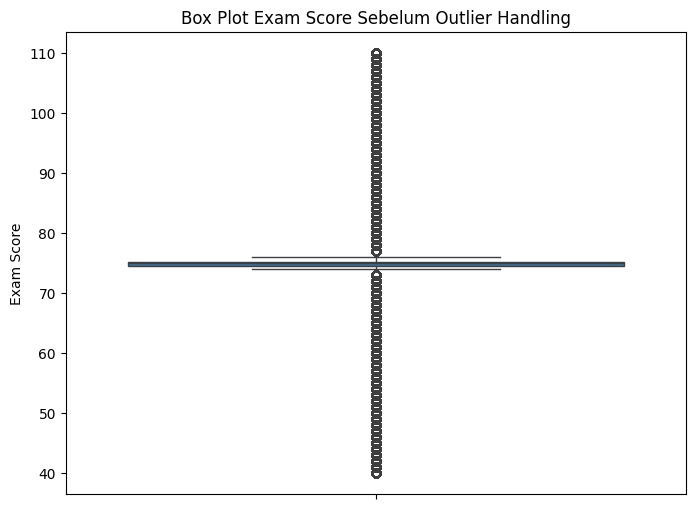

In [ ]:
import matplotlib.pyplot as plt
import seaborn as snsm

# Plot boxplot Exam_Score sebelum handle outlier
plt.figure(figsize=(8, 6))
sns.boxplot(y=merged_df['Exam_Score'])
plt.title('Box Plot Exam Score Sebelum Outlier Handling')
plt.ylabel('Exam Score')
plt.show()

3. Menghitung Q1, Q3, dan IQR dari kolom 'Exam_Score', lalu menggunakan batas outlier berdasarkan IQR untuk membatasi nilai outlier pada batas tersebut

In [ ]:
# Hitung Q1, Q3, dan IQR Exam_Score
Q1 = merged_df['Exam_Score'].quantile(0.25)
Q3 = merged_df['Exam_Score'].quantile(0.75)
IQR = Q3 - Q1

# Batas atas dan batas bawah
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

merged_df['Exam_Score'] = merged_df['Exam_Score'].clip(lower=lower_bound, upper=upper_bound)

# Verifikasi outlier sudah di handle dengan cek value diluar batas
outliers_after_handling = merged_df[(merged_df['Exam_Score'] < lower_bound) | (merged_df['Exam_Score'] > upper_bound)]

print(f"\nJumlah outlier setelah handling: {len(outliers_after_handling)}")

# Display statistik deskriptifnya
print("\nStatistik deskriptif Exam_Score:")
display(merged_df['Exam_Score'].describe())


Jumlah outlier setelah handling: 0

Statistik deskriptif Exam_Score:


,Exam_Score
count,401131.000000
mean,74.938152
std,0.921728
min,73.537929
25%,74.562018
50%,75.000000
75%,75.244744
max,76.268833


4. Membuat box plot untuk menunjukkan jumlah nilai yang hilang pada kolom 'Exam_Score' setelah nilai yang hilang diisi

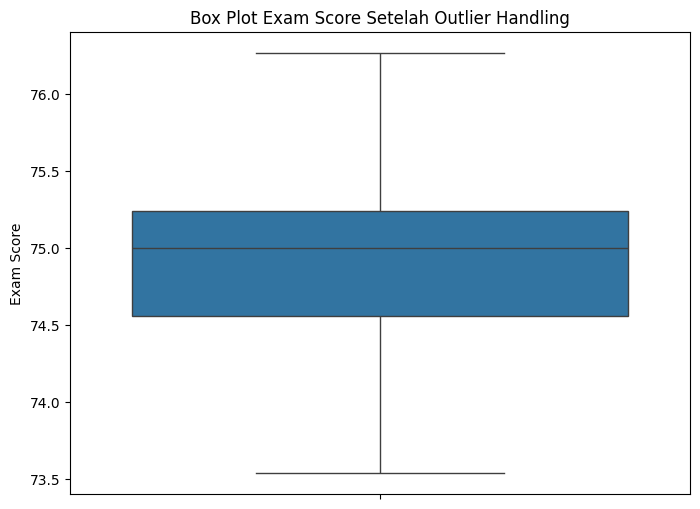

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot boxplot Exam_Score setelah outlier handling
plt.figure(figsize=(8, 6))
sns.boxplot(y=merged_df['Exam_Score'])
plt.title('Box Plot Exam Score Setelah Outlier Handling')
plt.ylabel('Exam Score')
plt.show()

5. Interpretasi

Dalam tahap ini, detecting dan handling outlier untuk nilai-nilai ujian yang terlalu tinggi atau rendah dan menyesuaikan supaya tidak terlalu jauh dari nilai rata-rata. Tujuannya supaya analisis nilai ujian lebih akurat, karena outlier bisa membuat hasil rata-rata menjadi salah.

# Data Grouping, Aggregation, Filtering, dan Applying Function

1. Membuat fungsi attendance_score untuk mengubah status kehadiran teks ('present', 'absent'.) menjadi nilai numerik (1 untuk hadir, 0 untuk tidak hadir) dan dimasukkan ke kolom 'Attendance_Status'

In [ ]:
def attendance_score(status):
    if status == 'present':
        return 1
    else:
        return 0

merged_df['Attendance_Status'] = merged_df['Attendance_Status'].apply(attendance_score)
display(merged_df.head())

,Student_ID,Date,Subject,Attendance_Status,Exam_Score,Full_Name,Grade_Level
0,S06592,2024-09-20,Arabic,1,74.933893,Dylan Harris,Grade 4
1,S01777,2025-01-22,Math,1,74.750456,Kristin Freeman,Grade 5
2,S07362,2024-12-03,Geography,1,74.562018,Robin Green,Grade 1
3,S12119,2024-03-16,Geography,0,73.537929,Henry Parker Md,Grade 3
4,S12119,2024-03-16,Geography,0,76.268833,Henry Parker Md,Grade 3


2. Menghitung rata-rata skor ujian dan skor kehadiran per siswa, per mata pelajaran, dan per tahun. Kemudian digabungkan kembali ke dataframe utama

In [ ]:
# Tambah kolom tahun
merged_df['Year'] = pd.to_datetime(merged_df['Date']).dt.year

# Hitung total hadir dan total pertemuan per siswa, per subject, per tahun
attendance_score = (merged_df.groupby(['Student_ID', 'Subject', 'Year']).agg({'Attendance_Status': ['sum', 'count']}))

# Rapikan nama kolom
attendance_score.columns = ['Total_Present', 'Total_Meetings']

# Hitung Attendance_Score dan ubah ke persentase
attendance_score['Attendance_Score'] = (attendance_score['Total_Present'] / attendance_score['Total_Meetings'] * 100).round(2)

# Merge kembali ke dataframe utama
merged_df = merged_df.merge(attendance_score[['Attendance_Score']],on=['Student_ID', 'Subject', 'Year'],how='left')

# Urutkan Student_ID dari awal
merged_df = merged_df.sort_values(by=['Student_ID', 'Subject', 'Year']).reset_index(drop=True)

display(merged_df.head(10))

,Student_ID,Date,Subject,Attendance_Status,Exam_Score,Full_Name,Grade_Level,Year,Attendance_Score
0,S00001,2024-05-15,Arabic,0,74.933893,Donna Williams,Grade 3,2024,55.56
1,S00001,2024-06-29,Arabic,1,74.933893,Donna Williams,Grade 3,2024,55.56
2,S00001,2024-10-04,Arabic,0,74.933893,Donna Williams,Grade 3,2024,55.56
3,S00001,2024-08-07,Arabic,1,74.933893,Donna Williams,Grade 3,2024,55.56
4,S00001,2024-03-12,Arabic,1,74.933893,Donna Williams,Grade 3,2024,55.56
5,S00001,2024-06-26,Arabic,1,74.933893,Donna Williams,Grade 3,2024,55.56
6,S00001,2024-05-09,Arabic,1,74.933893,Donna Williams,Grade 3,2024,55.56
7,S00001,2024-09-03,Arabic,0,74.933893,Donna Williams,Grade 3,2024,55.56
8,S00001,2024-12-04,Arabic,0,74.933893,Donna Williams,Grade 3,2024,55.56
9,S00001,2025-02-03,Arabic,0,74.933893,Donna Williams,Grade 3,2025,0.00


3. Menghapus baris data yang sama untuk setiap siswa, mata pelajaran, dan tahun yang sama

In [ ]:
# Drop duplikat biar tiap siswa hanya muncul sekali per Subject dan Year
merged_df = merged_df.drop_duplicates(subset=['Student_ID', 'Subject', 'Year'],keep='first').reset_index(drop=True)

display(merged_df.head(10))

,Student_ID,Date,Subject,Attendance_Status,Exam_Score,Full_Name,Grade_Level,Year,Attendance_Score
0,S00001,2024-05-15,Arabic,0,74.933893,Donna Williams,Grade 3,2024,55.56
1,S00001,2025-02-03,Arabic,0,74.933893,Donna Williams,Grade 3,2025,0.00
2,S00001,2024-04-24,English,0,75.206359,Donna Williams,Grade 3,2024,0.00
3,S00001,2024-11-07,Geography,1,74.562018,Donna Williams,Grade 3,2024,100.00
4,S00001,2025-01-09,Geography,0,74.562018,Donna Williams,Grade 3,2025,50.00
5,S00001,2024-08-15,History,0,75.084291,Donna Williams,Grade 3,2024,50.00
6,S00001,2025-02-10,History,0,75.084291,Donna Williams,Grade 3,2025,0.00
7,S00001,2024-11-07,Math,1,74.750456,Donna Williams,Grade 3,2024,60.00
8,S00001,2025-01-10,Math,1,74.750456,Donna Williams,Grade 3,2025,100.00
9,S00001,2024-06-11,Science,0,75.244744,Donna Williams,Grade 3,2024,33.33


4. Menghapus kolom 'Date' dan 'Attendance_Status' dari dataframe

In [ ]:
# Drop 'Date' dan 'Attendance_Status' kolom
merged_df = merged_df.drop(columns=['Date', 'Attendance_Status'])

# Display dataframe
display(merged_df.head(10))

,Student_ID,Subject,Exam_Score,Full_Name,Grade_Level,Year,Attendance_Score
0,S00001,Arabic,74.933893,Donna Williams,Grade 3,2024,55.56
1,S00001,Arabic,74.933893,Donna Williams,Grade 3,2025,0.00
2,S00001,English,75.206359,Donna Williams,Grade 3,2024,0.00
3,S00001,Geography,74.562018,Donna Williams,Grade 3,2024,100.00
4,S00001,Geography,74.562018,Donna Williams,Grade 3,2025,50.00
5,S00001,History,75.084291,Donna Williams,Grade 3,2024,50.00
6,S00001,History,75.084291,Donna Williams,Grade 3,2025,0.00
7,S00001,Math,74.750456,Donna Williams,Grade 3,2024,60.00
8,S00001,Math,74.750456,Donna Williams,Grade 3,2025,100.00
9,S00001,Science,75.244744,Donna Williams,Grade 3,2024,33.33


5. Membuat fungsi kelulusan untuk menentukan status kelulusan berdasarkan nilai ujian dan skor kehadiran, lalu menerapkannya untuk membuat kolom 'Status_Ujian'

In [ ]:
def kelulusan(row):
    if pd.isna(row['Exam_Score']):
        return 'Belum Ujian'
    elif row['Exam_Score'] >= 70 and row['Attendance_Score'] >= 75:
        return 'Lulus'
    else:
        return 'Tidak Lulus'

# Apply function untuk membuat kolom 'Status_Ujian'
merged_df['Status_Ujian'] = merged_df.apply(kelulusan, axis=1)

display(merged_df.head(10))

,Student_ID,Subject,Exam_Score,Full_Name,Grade_Level,Year,Attendance_Score,Status_Ujian
0,S00001,Arabic,74.933893,Donna Williams,Grade 3,2024,55.56,Tidak Lulus
1,S00001,Arabic,74.933893,Donna Williams,Grade 3,2025,0.00,Tidak Lulus
2,S00001,English,75.206359,Donna Williams,Grade 3,2024,0.00,Tidak Lulus
3,S00001,Geography,74.562018,Donna Williams,Grade 3,2024,100.00,Lulus
4,S00001,Geography,74.562018,Donna Williams,Grade 3,2025,50.00,Tidak Lulus
5,S00001,History,75.084291,Donna Williams,Grade 3,2024,50.00,Tidak Lulus
6,S00001,History,75.084291,Donna Williams,Grade 3,2025,0.00,Tidak Lulus
7,S00001,Math,74.750456,Donna Williams,Grade 3,2024,60.00,Tidak Lulus
8,S00001,Math,74.750456,Donna Williams,Grade 3,2025,100.00,Lulus
9,S00001,Science,75.244744,Donna Williams,Grade 3,2024,33.33,Tidak Lulus


6. Mengelompokkan data berdasarkan tingkat kelas dan mata pelajaran, kemudian menghitung rata-rata 'Exam_Score' untuk setiap kelompok

In [ ]:
aggregated = merged_df.groupby(['Grade_Level', 'Subject']).agg({'Exam_Score': 'mean'})
display(aggregated)

Exam_Score
Grade_Level Subject              
Grade 1     Arabic      74.915425
            English     75.064326
            Geography   74.692706
            History     74.986289
            Math        74.801455
            Science     75.127377
Grade 2     Arabic      74.935730
            English     75.109060
            Geography   74.695567
            History     75.009719
            Math        74.788906
            Science     75.065379
Grade 3     Arabic      74.935060
            English     75.112445
            Geography   74.712775
            History     75.040650
            Math        74.809280
            Science     75.123758
Grade 4     Arabic      74.929585
            English     75.066789
            Geography   74.665223
            History     75.018550
            Math        74.838840
            Science     75.149526
Grade 5     Arabic      74.902452
            English     75.108374
            Geography   74.688472
            History     75.030973
            Math        74.802682
            Science     75.142111

7. Mengelompokkan data berdasarkan ID siswa, nama lengkap, tahun, dan mata pelajaran, lalu menghitung rata-rata 'Exam_Score' dan 'Attendance_Score' untuk setiap kelompok



In [ ]:
rapor_avg = merged_df.groupby(['Student_ID', 'Full_Name','Year' , 'Subject']).agg({'Exam_Score': 'mean','Attendance_Score': 'mean'}).reset_index()
display(rapor_avg)

,Student_ID,Full_Name,Year,Subject,Exam_Score,Attendance_Score
0,S00001,Donna Williams,2024,Arabic,74.933893,55.56
1,S00001,Donna Williams,2024,English,75.206359,0.00
2,S00001,Donna Williams,2024,Geography,74.562018,100.00
3,S00001,Donna Williams,2024,History,75.084291,50.00
4,S00001,Donna Williams,2024,Math,74.750456,60.00
...,...,...,...,...,...,...
115977,S12156,Shannon Brown,2024,Math,76.000000,33.33
115978,S12156,Shannon Brown,2024,Science,73.537929,83.33
115979,S12156,Shannon Brown,2025,Arabic,74.933893,0.00
115980,S12156,Shannon Brown,2025,Geography,74.562018,100.00


8. Menghitung 'Final_Score' untuk setiap baris dengan menggabungkan 'Exam_Score' (dengan bobot 70%) dan 'Attendance_Score' (dengan bobot 30%)



In [ ]:
merged_df['Final_Score'] = (
    merged_df['Exam_Score'] * 0.7 +
    merged_df['Attendance_Score'] * 0.3
)

9. Mengelompokkan data berdasarkan ID siswa, tahun, dan nama lengkap, lalu menghitung rata-rata 'Final_Score' untuk setiap siswa per tahun

In [ ]:
rapor_final = merged_df.groupby(['Student_ID', 'Year', 'Full_Name'])['Final_Score'].mean().reset_index()
display(rapor_final)

,Student_ID,Year,Full_Name,Final_Score
0,S00001,2024,Donna Williams,67.419039
1,S00001,2025,Donna Williams,63.632865
2,S00002,2024,John Stafford,72.616373
3,S00002,2025,John Stafford,62.104804
4,S00003,2024,Chad Harper,65.794130
...,...,...,...,...
24254,S12154,2025,Chase Douglas,77.073601
24255,S12155,2024,Dawn Ward,67.895055
24256,S12155,2025,Dawn Ward,63.752198
24257,S12156,2024,Shannon Brown,68.587690


10. Menampilkan 10 siswa dengan 'Final_Score' tertinggi (Top 10) dan 10 siswa dengan 'Final_Score' terendah (Bottom 10)

In [ ]:
top10 = rapor_final.nlargest(10, 'Final_Score')
bottom10 = rapor_final.nsmallest(10, 'Final_Score')

print("\nTop 10 Students:")
display(top10)

print("\nBottom 10 Students:")
display(bottom10)


Top 10 Students:


,Student_ID,Year,Full_Name,Final_Score
362,S00182,2025,Jimmy Mcintosh,83.388183
739,S00371,2025,Kyle Smith,83.388183
1809,S00907,2025,Chelsea Robinson,83.388183
2067,S01036,2025,Justin Fisher,83.388183
2903,S01455,2025,Matthew Johnson,83.388183
3462,S01735,2025,Marie Bishop,83.388183
3914,S01961,2025,Marie Cole,83.388183
4047,S02029,2025,Benjamin Potter,83.388183
5028,S02521,2025,Jodi Shaw,83.388183
5755,S02886,2025,Kim Meadows,83.388183



Bottom 10 Students:


,Student_ID,Year,Full_Name,Final_Score
380,S00191,2025,Samantha Jackson,51.47655
2270,S01138,2025,John Sloan,51.47655
3005,S01506,2025,Kenneth Martin,51.47655
6125,S03071,2025,Jacob Gardner,51.47655
6547,S03282,2025,Roberta Mills,51.47655
7662,S03841,2025,Douglas Stewart,51.47655
7822,S03921,2025,Michael Doyle,51.47655
8378,S04199,2025,Holly Baxter,51.47655
8854,S04439,2025,Kenneth Williams,51.47655
9143,S04584,2025,Traci Roberts,51.47655


11. Interpretasi

Dalam tahap ini, grouping, agregation, filtering, dan applying function tujuannya untuk memproses data yang sudah dibersihkan supaya siap untuk dianalisis. Dengan mengelompokkan data, dapat melihat data per kategori seperti per siswa atau per mata pelajaran. Kemudian dengan agregasi, menghitung nilai ringkasan seperti rata-rata nilai atau total kehadiran. Filtering, untuk memastikan kita hanya menganalisis data yang relevan, seperti menghapus duplikat yang tidak perlu. Terakhir, menerapkan fungsi memungkinkan kita membuat perhitungan khusus seperti skor kehadiran numerik, skor akhir gabungan, dan status kelulusan berdasarkan kriteria tertentu. Hasil dari tahap ini adalah dataframe yang terstruktur.